In [2]:
using MarineHydro
import Meshes as Meshes
using CairoMakie: CairoMakie as Makie
using Unitful: m, ustrip, Length, u, @u_str
using LinearAlgebra: cross, dot, norm, diag
using DifferentiationInterface 
import ForwardDiff 
using FiniteDifferences
using Test
import Plots as Plots

In [33]:
# Make polynomial function

# Inputs
# des_vars
N_des_var = 5
N_a = N_des_var-1 # number of coefficients
a_vec_trunc = -ones(N_a-1)*0.2
d=2
r_1=3
des_vars = vcat(d,r_1,a_vec_trunc)
# N_r
N_r = 5 # number of radii in mesh


function des_vars_to_a_vec(des_vars)

    N_des_vars = length(des_vars)
    N_a = N_des_var-1
    poly_series = zero(des_vars[1])
    d=des_vars[1]
    r_1=des_vars[2]
    a_vec_trunc=des_vars[3:end]
    for i in 2:N_a
        a_i = a_vec_trunc[i-1]
        d_i = d^i
        poly_series += a_i*d_i
    end

    a_1 = (r_1 - poly_series)/d
    a_vec = vcat(a_1,a_vec_trunc)

    return a_vec
end

function r_fun(z,des_vars)
    N_des_vars = length(des_vars)
    N_a = N_des_var-1
    d=des_vars[1]
    a_vec = des_vars_to_a_vec(des_vars)
    r_val=zero(des_vars[1])
    for i in 1:N_a
        r_val += a_vec[i]*(z+d)^i
    end
    return r_val
end

function a_vec_to_rz(a_vec,des_vars,N_r)
    N_des_vars = length(des_vars)
    N_a = N_des_var-1
    d=des_vars[1]
    r_1=des_vars[2]
    i_vec = collect(1:N_a)
    z_vals = collect(range(-0.0,-d,length=N_r))
    r_vals = [r_fun(z,des_vars) for z in z_vals]
    return r_vals, z_vals
end

function des_vars_to_rz(des_vars,N_r)
    a_vec = des_vars_to_a_vec(des_vars)
    r_vals, z_vals = a_vec_to_rz(a_vec,des_vars,N_r)
    return r_vals, z_vals
end

r_vals, z_vals = des_vars_to_rz(des_vars,N_r)


([3.000000000000001, 4.312500000000001, 3.7, 2.0625000000000004, 0.0], [0.0, -0.5, -1.0, -1.5, -2.0])

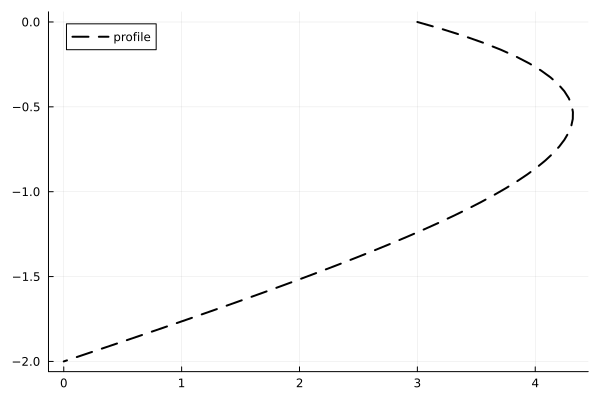

In [34]:
r_vals, z_vals = des_vars_to_rz(des_vars,50)


p1 = Plots.plot(r_vals, z_vals, label="profile", color=:black, linestyle=:dash, linewidth=2)
# Plots.plot!(p1, x_vals, x -> diffable_abs(x, purt1), label="purt = $purt1", linewidth=2)
# Plots.title!(p1, "Smooth Absolute Value")
# Plots.xlabel!(p1, "x")
# Plots.ylabel!(p1, "f(x)")

# p2 = Plots.plot(x_vals, x -> sign(x), label="True sign(x)", color=:black, linestyle=:dash, linewidth=2)
# Plots.plot!(p2, x_vals, x -> diffable_sign(x, purt2), label="purt = $purt2", linewidth=2)
# Plots.title!(p2, "Smooth Sign Function")
# Plots.xlabel!(p2, "x")
# Plots.ylabel!(p2, "f(x)")

# # 5. Combine them into a side-by-side layout
# Plots.plot(p1, p2, layout=(1, 2), size=(900, 400))

In [ ]:
#################### LID MESH ########################

function rectangular_lid_mesh(x_min::Real, x_max::Real, y_min::Real, y_max::Real, n_panels_x::Int, n_panels_y::Int, z_value::Real=0.0)
    # 1. Create a flat 2D CartesianGrid
    start_point = Meshes.Point(x_min, y_min)
    end_point   = Meshes.Point(x_max, y_max)
    grid = Meshes.CartesianGrid(start_point, end_point, dims=(n_panels_x, n_panels_y))

    # 2. Extract the 2D vertices and elevate them to 3D
    verts2d = Meshes.vertices(grid)
    verts3d = map(verts2d) do v
        vec_coords = Meshes.to(v)
        z_with_unit = z_value * u"m"
        Meshes.Point(vec_coords[1], vec_coords[2], z_with_unit)
    end

    # 3. Extract the connectivity indices natively from the grid elements
    # This unpacks the quad-panel connections explicitly
    connec = [Meshes.connect(Tuple(e.indices)) for e in Meshes.topology(grid)]

    # 4. Construct the SimpleMesh using an explicit unstructured configuration
    return Meshes.SimpleMesh(verts3d, connec)
end


function generate_lid_for_axisymmetric_geom(radius_at_surface, show_lid)

    # fixed parameters
    x_mean = 0.0
    y_mean = 0.0
    reduce_scale = 0.95
    n_panels_x = 5
    n_panels_y = 5
    z_value = -1e-3

    # changable parameters
    width = radius_at_surface * (2/sqrt(2)) * reduce_scale
    x_min_lid = x_mean - width/2
    x_max_lid = x_mean + width/2
    y_min_lid = y_mean - width/2
    y_max_lid = y_mean + width/2   

    mesh = rectangular_lid_mesh(x_min_lid, x_max_lid, y_min_lid, y_max_lid, n_panels_x, n_panels_y, z_value)
    if show_lid
        fig = Makie.Figure()
        ax = Makie.Axis3(fig[1, 1], title = "Rectangular Lid Mesh", aspect = :data)
        Meshes.viz!(ax, mesh, color=:gold, showsegments=true, segmentcolor=:grey50, segmentsize=0.25)
        display(fig)
    end
    return Mesh(mesh)
end


########################## MESH #######################

function des_vars_to_rz_vals(des_vars)
    a_vec = des_vars_to_coeffs()
    return r_vals, z_vals
end

MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)


function arbitrary_axisymmetric_mesh(x::Vector, n_theta, n_bottom, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-0.0, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end




function arbitrary_axisymmetric_mesh(x)
    return arbitrary_axisymmetric_mesh(x, 20, 3, false)
end


function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end